# LeetCode #20: Valid Parentheses

https://leetcode.com/problems/valid-parentheses/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(n)$ |
| **Stack** ★ | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force
Repeatedly scan the string and delete adjacent matched pairs — "()", "[]", "{}" — until no changes occur, then check if the result is empty. Each scan is $O(n)$; up to $n/2$ scans may be needed, giving $O(n^2)$ overall.

### Optimal: Stack ★
Push each opening bracket onto a stack. On each closing bracket, pop the top and verify it is the matching opener — return false immediately if it is not, or if the stack is empty. The string is valid iff the stack is empty at the end.

**Why this is better than Brute Force:** Single linear scan with $O(1)$ work per character; no string mutation or repeated traversals.

**Constraints:**
* 1 ≤ s.length ≤ $10^4$
* s consists of parentheses only '()[]{}'

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsValid(string s) {
        var stack = new Stack<char>();
        foreach (char c in s) {
            if (c is '(' or '[' or '{') {
                stack.Push(c);
            } else {
                // Closing bracket must match the most-recently-opened bracket
                if (stack.Count == 0) return false;
                char top = stack.Pop();
                if (c == ')' && top != '(') return false;
                if (c == ']' && top != '[') return false;
                if (c == '}' && top != '{') return false;
            }
        }
        return stack.Count == 0;
    }
}

### Python

In [ ]:
class Solution:
    def isValid(self, s: str) -> bool:
        stack = []
        matching = {')': '(', ']': '[', '}': '{'}

        for c in s:
            if c in '([{':
                stack.append(c)
            else:
                # Closing bracket must match the most-recently-opened bracket
                if not stack or stack[-1] != matching[c]:
                    return False
                stack.pop()

        return not stack

### Go

In [ ]:
func isValid(s string) bool {
    stack := []rune{}
    matching := map[rune]rune{')': '(', ']': '[', '}': '{'}

    for _, c := range s {
        if c == '(' || c == '[' || c == '{' {
            stack = append(stack, c)
        } else {
            // Closing bracket must match the most-recently-opened bracket
            if len(stack) == 0 || stack[len(stack)-1] != matching[c] {
                return false
            }
            stack = stack[:len(stack)-1]
        }
    }
    return len(stack) == 0
}

### Rust

In [ ]:
pub fn is_valid(s: String) -> bool {
    let mut stack = Vec::new();

    for c in s.chars() {
        match c {
            '(' | '[' | '{' => stack.push(c),
            _ => {
                // Closing bracket must match the most-recently-opened bracket
                let expected = match c {
                    ')' => '(',
                    ']' => '[',
                    '}' => '{',
                    _   => return false,
                };
                if stack.pop() != Some(expected) {
                    return false;
                }
            }
        }
    }
    stack.is_empty()
}

## Example Scenarios

**1. Common Case**
**Input:** s = "()[]{}"
Each bracket is its own pair: '(' pushed, ')' pops it ✓; '[' pushed, ']' pops ✓; '{' pushed, '}' pops ✓. Stack empty at end. Output: true.

**2. Slightly Complex — nested brackets**
**Input:** s = "([])"
'(' pushed → stack: [(]. '[' pushed → stack: [(, []. ']' closes: top='[' matches ✓, pop → stack: [(]. ')' closes: top='(' matches ✓, pop → stack: []. Stack empty. Output: true.

**3. Edge Case: Time Factor — deeply nested valid string**
**Input:** s = "({[({[" + "]})}]}" (alternating opens then closes, depth = $n/2$)
Stack grows to depth $n/2$ during the opening half, then unwinds one-by-one during the closing half. Every character requires one push or pop — full $O(n)$ scan with no early exit. Output: true.

**4. Edge Case: Space Factor — all opening brackets**
**Input:** s = "(((((" (n = 10,000 '(' characters)
Every character is pushed; the stack fills to capacity n. No closing bracket ever triggers a pop. At the end, stack.Count = 10,000 ≠ 0 → false. Worst-case stack space: $O(n)$.

**5. Almost-Impossible but Plausible — interleaved mismatched types**
**Input:** s = "([)]"
'(' pushed → [(]. '[' pushed → [(, []. ')' closes: top='[' ≠ '(' → return false immediately. Output: false. Even though the counts of each bracket type are balanced, the order is wrong.

## Infographic

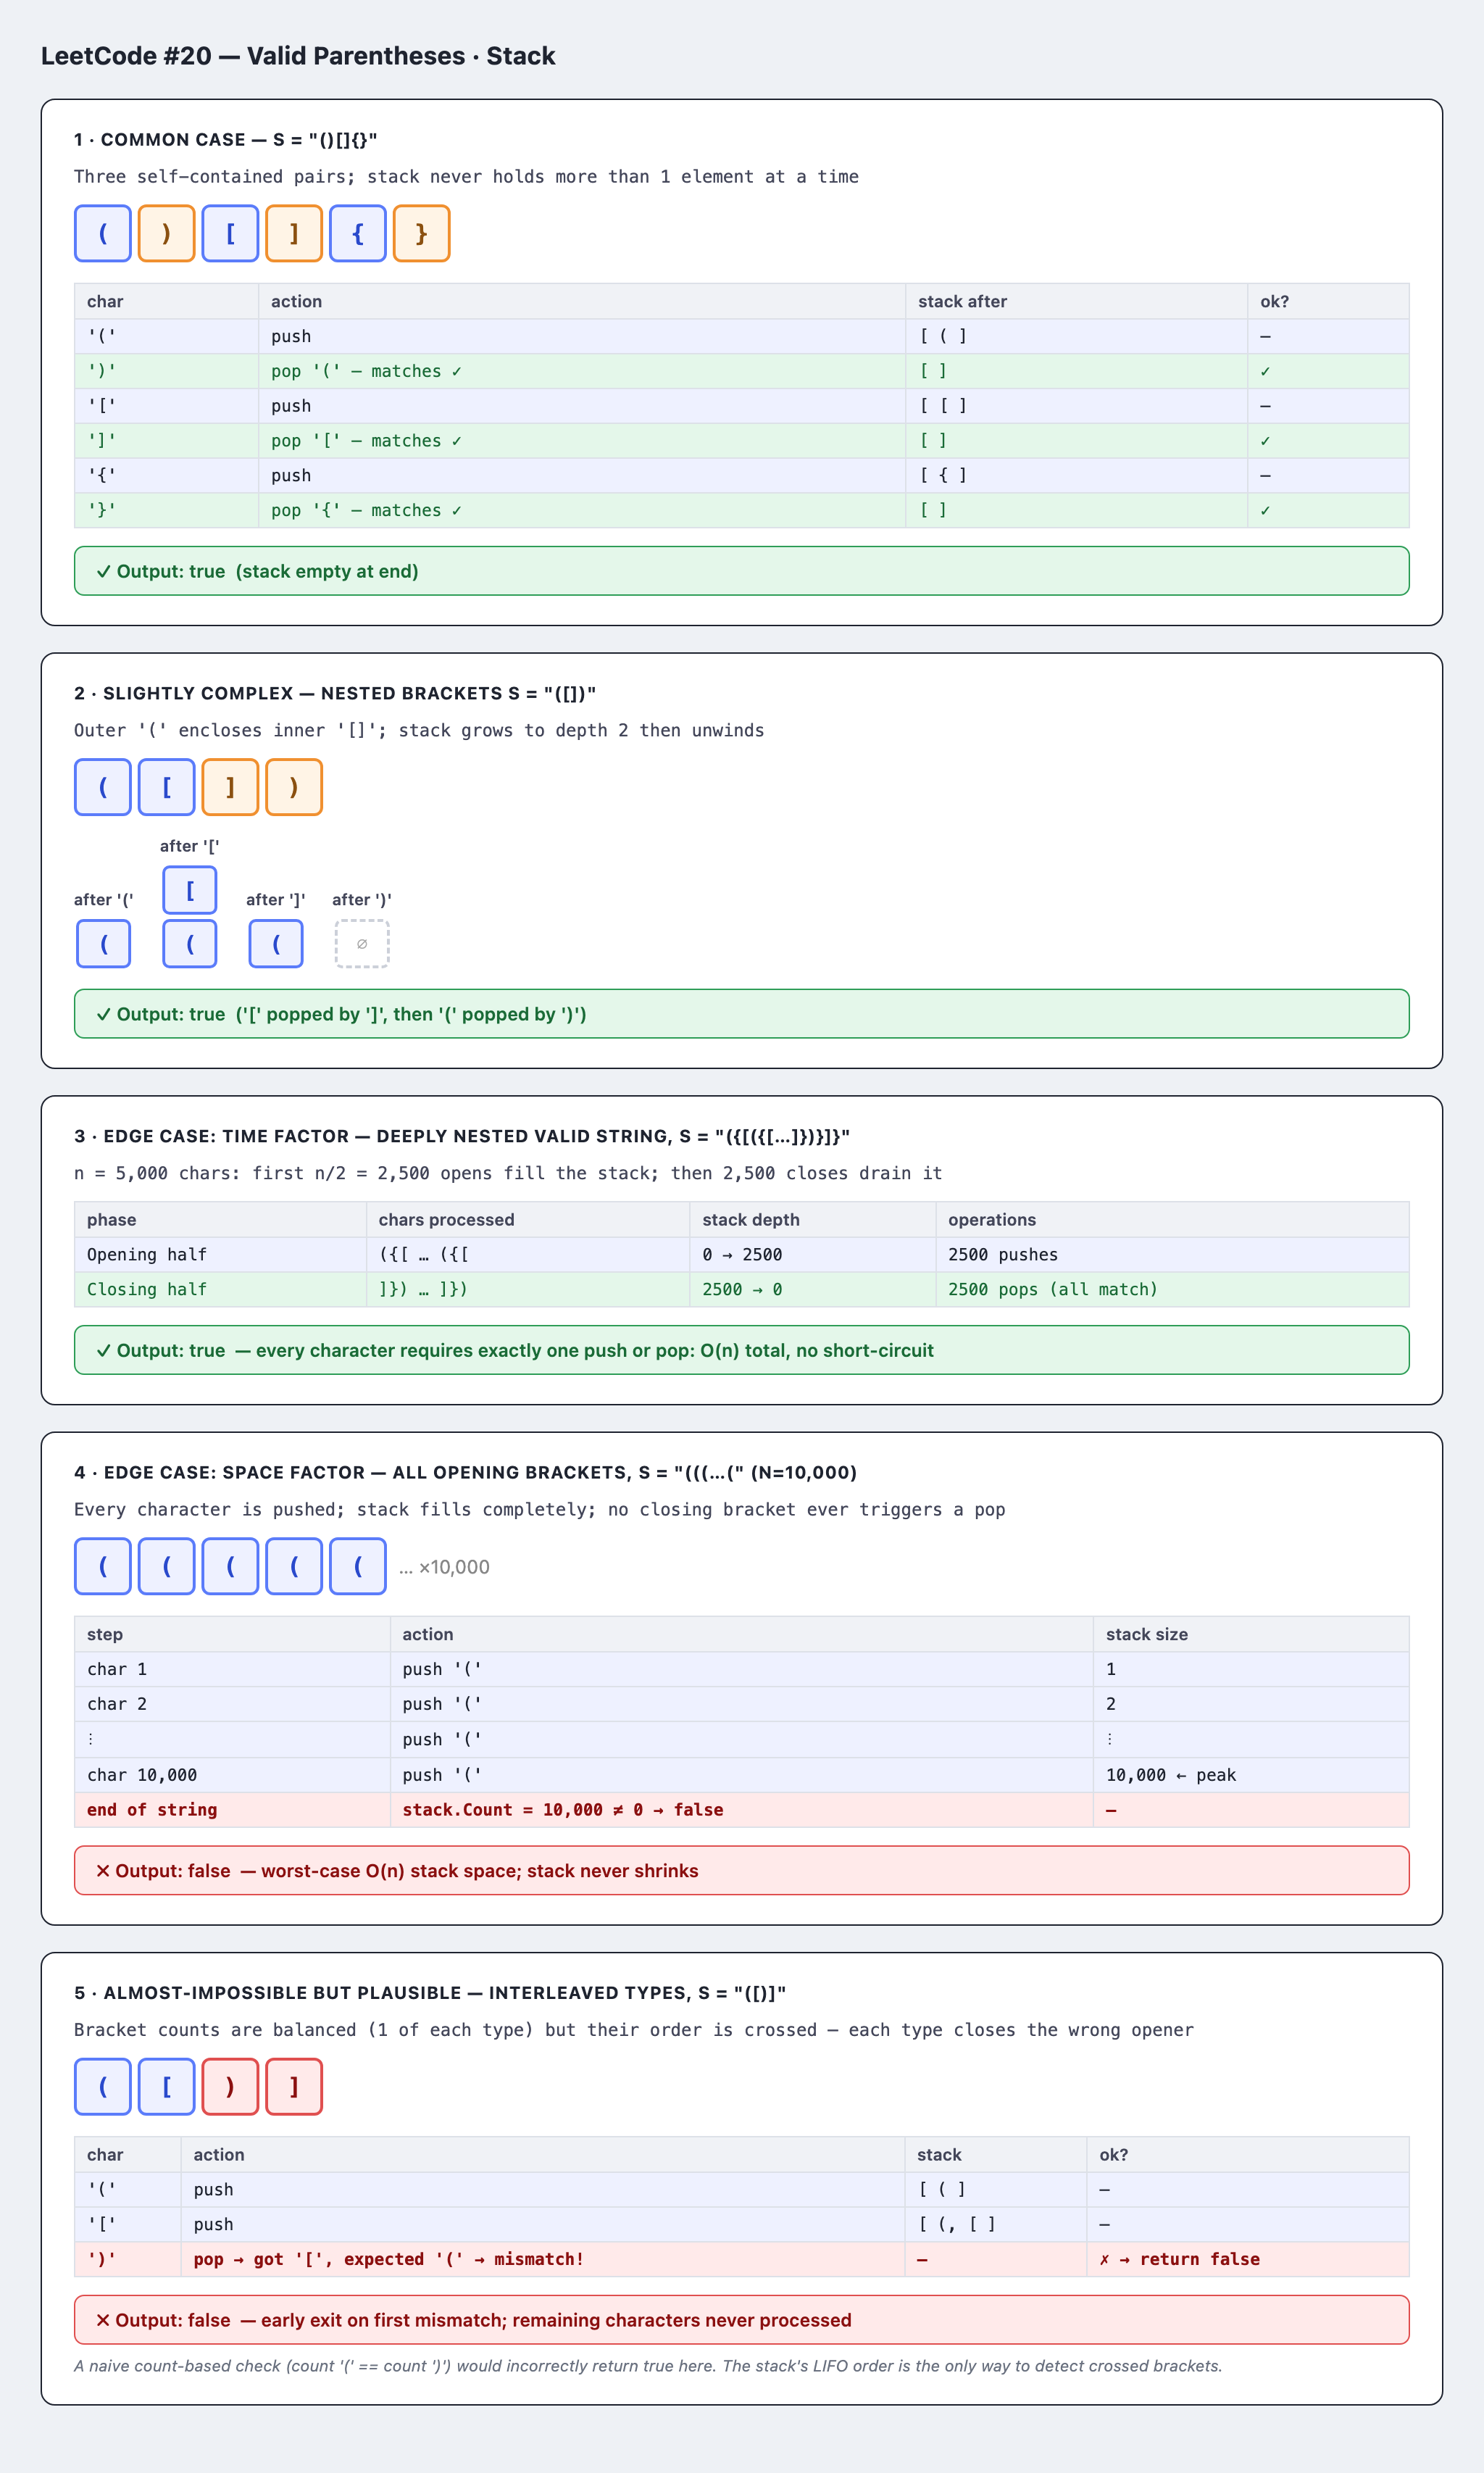